# Classification models
CDS Class, prepared by Prof. Dorien Herremans

You can run this lab in Playground mode and add your own code at the #todo items and final questions.


---






Let's start by loading the necessary libraries for this class. The main libraries used are numpy and pandas for data handling and [scikit learn (sklearn)](https://scikit-learn.org/stable/) for classification models.


In [1]:
import matplotlib.pyplot as plt # plotting library
import numpy as np # library for numerical calculations
import pandas as pd # library for reading csv files

## Walkthrough example of different classification methods

To become familiar with the classification models, please follow the instructions below.

### Problem description and preparing dataset

Let's start doing some classification on the Heart Disease dataset from Kaggle at https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data. The dataset has 303 patients and 13 features for each patient.

You can find the dataset at the link above, or directly load it like shown below:


In [2]:
# Download the csv file to your root folder:
!wget -P / -c 'https://dorienherremans.com/drop/CDS/classification/heart.csv'

data = pd.read_csv('heart.csv') # loading dataset

data.head() #check if it's loaded correctly

--2026-02-26 01:20:41--  https://dorienherremans.com/drop/CDS/classification/heart.csv
Resolving dorienherremans.com (dorienherremans.com)... 184.154.70.198
Connecting to dorienherremans.com (dorienherremans.com)|184.154.70.198|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11328 (11K) [text/csv]
Saving to: ‘heart.csv’

eart.csv            100%[===================>]  11.06K  --.-KB/s    in 0s      

2026-02-26 01:20:41 (127 MB/s) - ‘heart.csv’ saved [11328/11328]



,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


Let's make the data nicer. Since the column headers are a bit heard to read, we can override them to provide more easy to understand labels:

In [3]:
# Give a better name to each column
data.columns = ['age', 'sex', 'chest_pain_type', 'resting_blood_pressure', 'cholesterol',
                'fasting_blood_sugar', 'rest_ecg', 'max_heart_rate_achieved',
       'exercise_induced_angina', 'st_depression', 'st_slope', 'num_major_vessels',
       'thalassemia', 'target']

In [5]:
data.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,rest_ecg,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


Let's check how balanced our dataset is.

/tmp/ipython-input-683/3611785951.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="target", data=data, palette="muted");


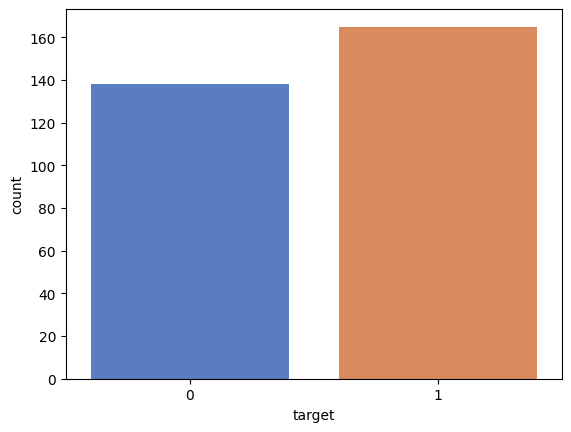

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
#breakdown by class
sns.countplot(x="target", data=data, palette="muted");

It's almost balanced, but not entirely, so during evaluation, let's make sure to check F1 values and AUC instead of just accuracy.

We also need to make sure that the system recognises our data as being categorical appropriately.

In [6]:
data.dtypes

,0
age,int64
sex,int64
chest_pain_type,int64
resting_blood_pressure,int64
cholesterol,int64
fasting_blood_sugar,int64
rest_ecg,int64
max_heart_rate_achieved,int64
exercise_induced_angina,int64
st_depression,float64


This looks good. Everything is an integer, except for the continuous variables. In the case where categories are stored as strings, you need to correct this with:

data['Class'] = pd.Categorical(data['Class'])

data['Class'] = data['Class'].cat.codes

In our case all is well.

Looking at the header, the prediction task is now clear: we need to predict if target = 1, meaning heart disease is present.

To properly evaluate models, we **create a test and training set** with 30% split using train_test_split.

In [7]:
from sklearn.model_selection import train_test_split
# data = pd.get_dummies(data, drop_first=True)
# We split the data up into a test set and a training set, 30 - 70 %
# train_test_split
# First argument: x data is all data without class column
# Second argument:  this is the class label column
# Random state = 0: ensures the train and test splitting is deterministic.
#Otherwise every student would get a different train test split.
X_train, X_test, y_train, y_test = train_test_split(data.drop('target', axis=1),
                                                    data['target'],
                                                    test_size=0.3,
                                                    random_state=0)

Most classifiers will work best if the data is normalized. We can easily do this by using the MinMaxScaler fuction.

TODO: fit the X_train data normalization factors into the x_scaler using `fit(X_train)`


In [8]:
from sklearn.preprocessing import MinMaxScaler

# define a new scaler:
x_scaler = MinMaxScaler()

# fit the normalization on the training set:
x_scaler.fit(X_train)

# then create new and normalized training/test sets:
X_train_norm = x_scaler.transform(X_train)
X_test_norm = x_scaler.transform(X_test)

### Model 1: Decision Trees

Let's import the sklearn library for CART decision trees, and define a variable 'model' to hold our CART tree model. We can specify some pruning/early stopping parameters so that the size of the tree can be adjusted.

In [9]:
# from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

model = tree.DecisionTreeClassifier(max_depth=3, min_samples_leaf=1)
# Using default parameters

Let's train the model by passing it our training data X_train and labels y_train. Note that decision trees don't need normalized data, in this case it may be easier to understand with the original data (so we are using X_train, not X_train_norm as we do in the other models).

you can use the fit command to train the model: `model.fit(xvariables, yvariables)` (change the variables to the correct training data)

In [10]:
model.fit(X_train, y_train)# Training model

DecisionTreeClassifier(max_depth=3)

Notice how the options above let you tweek the classifier (e.g. criterion Gini coefficient). This model trained really fast! But how good is it?

I've emphasized the importance of evaluating models using multiple metrics in class. Let's **define a function called
evaluate_on_training_set, which will print out all of out metrics**. This will save us some time throughout the lab.


TODO: print the auc score `using (replace variables): roc_auc_score(realvalue, predicted value)`



In [11]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score

def evaluate_on_training_set(y_test, y_pred):
  # Calculate AUC
  print("AUC is: ", roc_auc_score(y_test, y_pred))

  # print out recall and precision
  print(classification_report(y_test, y_pred))

  # print out confusion matrix
  print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred))

  # # calculate points for ROC curve
  fpr, tpr, thresholds = roc_curve(y_test, y_pred)

  # Plot ROC curve
  plt.plot(fpr, tpr, label='ROC curve (area = %0.3f)' % roc_auc_score(y_test, y_pred))
  plt.plot([0, 1], [0, 1], 'k--')  # random predictions curve
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.0])
  plt.xlabel('False Positive Rate or (1 - Specifity)')
  plt.ylabel('True Positive Rate or (Sensitivity)')
  plt.title('Receiver Operating Characteristic')

Using this new function we can now make predictions for our newly trained model 'model' and get the evaluation metrics:


[0 1 1 0 1 0 0 0 0 0 1 1 0 1 1 1 0 1 0 1 1 0 1 0 1 1 0 0 1 1 0 0 1 1 1 1 0
 1 0 0 1 0 1 0 1 1 0 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1 0
 0 1 0 0 1 1 0 0 0 1 0 1 0 1 0 1 0]
225    0
152    1
228    0
201    0
52     1
      ..
253    0
293    0
76     1
272    0
238    0
Name: target, Length: 91, dtype: int64
AUC is:  0.8104448742746615
              precision    recall  f1-score   support

           0       0.86      0.73      0.79        44
           1       0.78      0.89      0.83        47

    accuracy                           0.81        91
   macro avg       0.82      0.81      0.81        91
weighted avg       0.82      0.81      0.81        91

Confusion Matrix: 
 [[32 12]
 [ 5 42]]


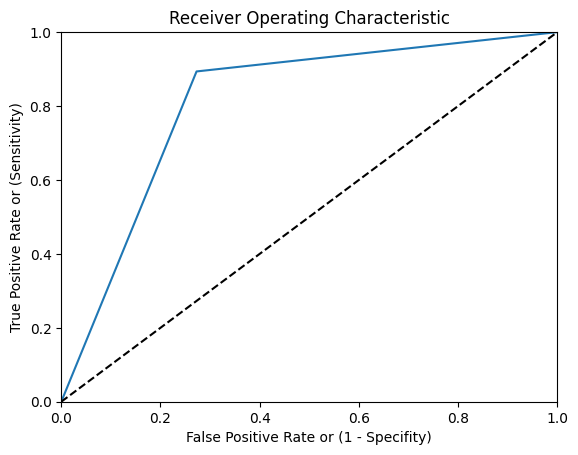

In [12]:
y_pred = model.predict(X_test) # Predicting labels for our test set using model
print (y_pred)
print(y_test)
evaluate_on_training_set(y_test, y_pred) #evaluate our model using new function

Finally, what does the actual tree look like? You can experiment yourself how the tree (and the accuracy) changes when we set different pruning parameters.

[Text(0.5, 0.875, 'x[2] <= 0.5\ngini = 0.494\nsamples = 212\nvalue = [94, 118]'),
 Text(0.25, 0.625, 'x[11] <= 0.5\ngini = 0.415\nsamples = 102\nvalue = [72, 30]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'x[12] <= 2.5\ngini = 0.492\nsamples = 48\nvalue = [21, 27]'),
 Text(0.0625, 0.125, 'gini = 0.328\nsamples = 29\nvalue = [6, 23]'),
 Text(0.1875, 0.125, 'gini = 0.332\nsamples = 19\nvalue = [15, 4]'),
 Text(0.375, 0.375, 'x[0] <= 63.5\ngini = 0.105\nsamples = 54\nvalue = [51, 3]'),
 Text(0.3125, 0.125, 'gini = 0.0\nsamples = 43\nvalue = [43, 0]'),
 Text(0.4375, 0.125, 'gini = 0.397\nsamples = 11\nvalue = [8, 3]'),
 Text(0.75, 0.625, 'x[9] <= 1.95\ngini = 0.32\nsamples = 110\nvalue = [22, 88]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'x[7] <= 152.5\ngini = 0.255\nsamples = 100\nvalue = [15, 85]'),
 Text(0.5625, 0.125, 'gini = 0.438\nsamples = 34\nvalue = [11, 23]'),
 Text(0.6875, 0.125, 'gini = 0.114\nsamples = 66\nvalue = [4, 62]'),
 Text(0.875, 0.375, 'x[10] <= 

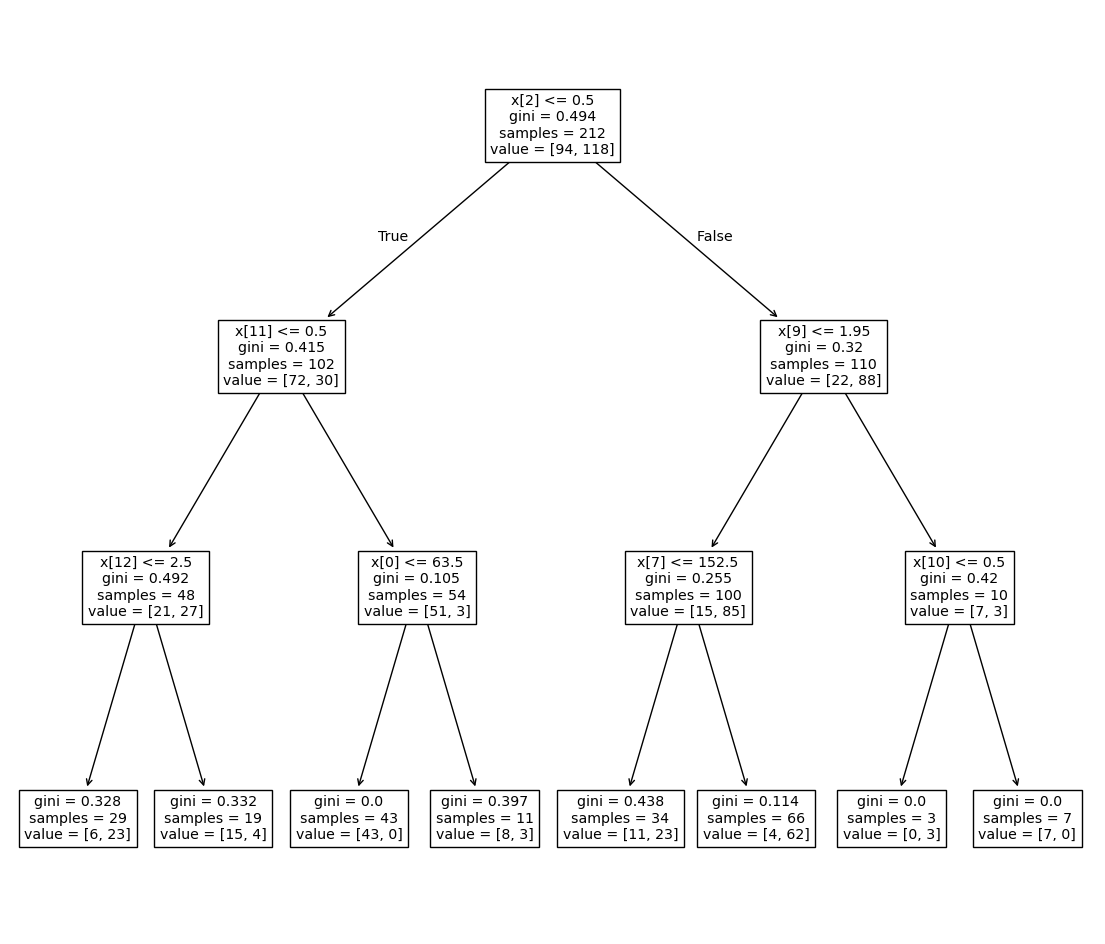

In [13]:
plt.figure(figsize=(14,12))
tree.plot_tree(model)

### Model 2: K Nearest Neighbor Classifier

Let's explore the kNN algorithm. As you've seen in class. It's a very simple algorithm, however, it needs a lot of time to compute all distances.

Similar to before, we first load the library and define the model with parameters (here only the parameter k is needed).

In [20]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5) # Define the model with parameters

We can then proceed to train the model using the fit command and evaluate it using the function we defined before:

AUC is:  0.8225338491295938
              precision    recall  f1-score   support

           0       0.85      0.77      0.81        44
           1       0.80      0.87      0.84        47

    accuracy                           0.82        91
   macro avg       0.83      0.82      0.82        91
weighted avg       0.83      0.82      0.82        91

Confusion Matrix: 
 [[34 10]
 [ 6 41]]


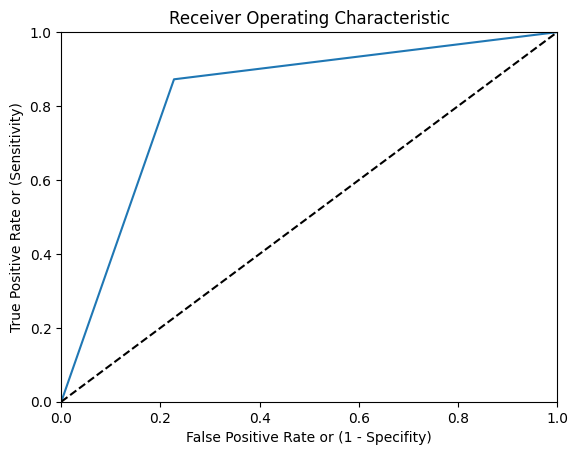

In [21]:
model.fit(X_train_norm, y_train) # Training the model

# Evaluate the model:
y_pred = model.predict(X_test_norm) # Predicting labels for our test set using trained model
evaluate_on_training_set(y_test, y_pred) #evaluate our model using newly defined function

It's extremely important to set a good value for k, so you will need to test this. E.g. try running the above code with k = 5. See any change? Your F1 scores should go up!

### Model 3: Logistic Regression

Let's move on to a very powerful, yet fast model: Logistic Regression. Again, we start by loading the library and defining the model together with its parameters.

In this case, multi_class auto will detect the number of classes automatically, C is our regularisation parameter, and solver is the optimization algorithm used to fit the model:
* For small datasets, ‘liblinear’ is a good choice, whereas ‘sag’ and ‘saga’ are faster for large ones.
* For multiclass problems, only ‘newton-cg’, ‘sag’, ‘saga’ and ‘lbfgs’ handle multinomial loss; ‘liblinear’ is limited to one-versus-rest schemes.
* ‘newton-cg’, ‘lbfgs’, ‘sag’ and ‘saga’ handle L2 or no penalty
* ‘liblinear’ and ‘saga’ also handle L1 penalty
* ‘saga’ also supports ‘elasticnet’ penalty
* ‘liblinear’ does not handle no penalty

In [22]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(C=1.0, multi_class='auto', solver='lbfgs')
# Define the model with parameters

We can the train and evaluate the model like usual:

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


AUC is:  0.7990812379110253
              precision    recall  f1-score   support

           0       0.86      0.70      0.78        44
           1       0.76      0.89      0.82        47

    accuracy                           0.80        91
   macro avg       0.81      0.80      0.80        91
weighted avg       0.81      0.80      0.80        91

Confusion Matrix: 
 [[31 13]
 [ 5 42]]


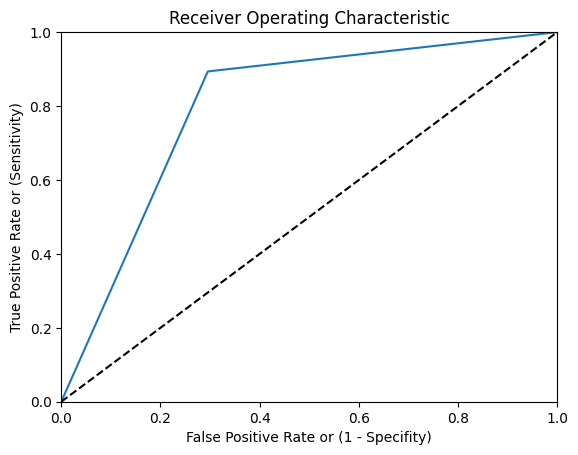

In [23]:
model.fit(X_train_norm, y_train) # Training the model

y_pred = model.predict(X_test_norm) # Predicting labels for our test set using trained model
evaluate_on_training_set(y_test, y_pred) #evaluate our model using newly defined function


This is a fast model again, with rather good output.

### Model 4: Gaussian Naive Bayes

Let's create a Naive Bayes model. There are a [number of variants on this model to choose](https://scikit-learn.org/stable/modules/naive_bayes.html) from in Scikit learn, let's pick the Gaussian variant. Same thing as always, we load the library and define the model:

In [24]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB() # Define the model with parameters

We can proceed to train (fit) the model and evaluate:

AUC is:  0.799806576402321
              precision    recall  f1-score   support

           0       0.84      0.73      0.78        44
           1       0.77      0.87      0.82        47

    accuracy                           0.80        91
   macro avg       0.81      0.80      0.80        91
weighted avg       0.81      0.80      0.80        91

Confusion Matrix: 
 [[32 12]
 [ 6 41]]


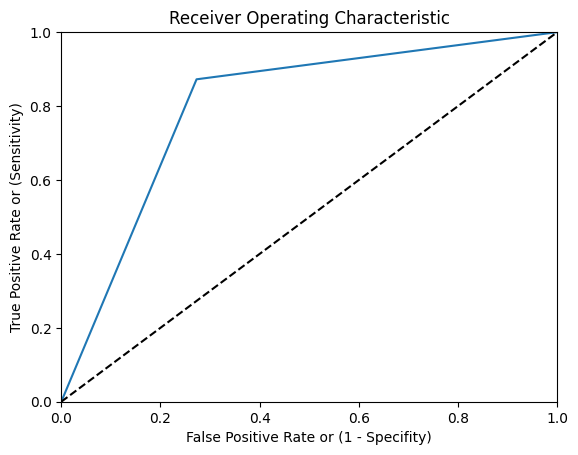

In [25]:
model.fit(X_train_norm, y_train) # Training the model

y_pred = model.predict(X_test_norm) # Predicting labels for our test set using trained model
evaluate_on_training_set(y_test, y_pred) #evaluate our model using newly defined function

Not a bad result! Gaussian models often perform well with smaller datasets as they fit the limited data to a distribution.

### Model 5: SVM

Support Vector Machines offer a very powerful way to transform our data by implementing a 'kernel trick'. Hence, when we define our model, we need to specify our kernel. The results will be highly dependant on the kernel value and the regularisation parameter C.

The kernel can be: ‘linear’, ‘poly’, ‘rbf’, ‘sigmoid’, ‘precomputed’. If none is given, ‘rbf’ will be used.

In [26]:
from sklearn.svm import SVC
model = SVC(C=10, gamma='auto', kernel='rbf')
model.fit(X_train_norm, y_train)

SVC(C=10, gamma='auto')

As usual, we use the exact same commands to train and evaluate the model:

AUC is:  0.7983558994197292
              precision    recall  f1-score   support

           0       0.88      0.68      0.77        44
           1       0.75      0.91      0.83        47

    accuracy                           0.80        91
   macro avg       0.82      0.80      0.80        91
weighted avg       0.82      0.80      0.80        91

Confusion Matrix: 
 [[30 14]
 [ 4 43]]


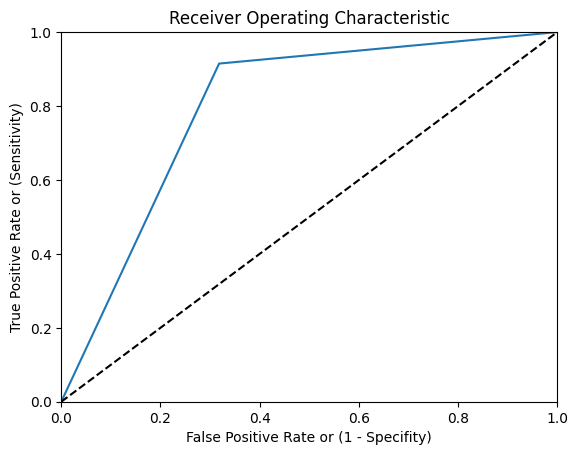

In [27]:
model.fit(X_train_norm, y_train) # Training SVM

y_pred = model.predict(X_test_norm) # Predicting labels for our test set using trained model
evaluate_on_training_set(y_test, y_pred) #evaluate our model using newly defined function

##### optimizing SVM using GridSearch
Were you expecting better results from such a powerful model? Let's tweek the parameters to improve our accuracy...

We will be using Grid Search to tune parameters and try a range:
- with kernel rbf, try varying gamma (which is a coefficient in the rbf kernel) to be 1e-3 or 1e-4; and vary C to be 1, 10, or 100.
- with linear kernel (there is no gamma here), try varying C to be 1, 10, and 100.

These values are stored as tuned_parameters.

In [28]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

tuned_parameters = [{'kernel': ['rbf'],
                     'gamma': [1e-3, 1e-4],
                     'C': [1, 10, 100]},
                    {'kernel': ['linear'],
                     'C': [1, 10, 100]}]

Using the above parameters, we can run a GridSearch algorithm to optimize the AUC score. The verbose output will output the process; n_jobs will parallize the computation over 4 processors; 2-fold CV is used during the search (cv = 2).

(if here you happen to get an error, try `roc_auc_ovr`)

In [29]:
# we define the grid search model for SVM:
clf = GridSearchCV(SVC(), tuned_parameters, cv=2,
                   scoring='roc_auc', verbose=1, n_jobs=4)

# train the model on the training set:
clf.fit(X_train_norm, y_train)

Fitting 2 folds for each of 9 candidates, totalling 18 fits


GridSearchCV(cv=2, estimator=SVC(), n_jobs=4,
             param_grid=[{'C': [1, 10, 100], 'gamma': [0.001, 0.0001],
                          'kernel': ['rbf']},
                         {'C': [1, 10, 100], 'kernel': ['linear']}],
             scoring='roc_auc', verbose=1)

Once this is trained we can again look at what the best parameters are and how well the model performs.

Best parameter set found on development set:
{'C': 10, 'kernel': 'linear'} 

AUC is:  0.8210831721470019
              precision    recall  f1-score   support

           0       0.89      0.73      0.80        44
           1       0.78      0.91      0.84        47

    accuracy                           0.82        91
   macro avg       0.84      0.82      0.82        91
weighted avg       0.83      0.82      0.82        91

Confusion Matrix: 
 [[32 12]
 [ 4 43]]


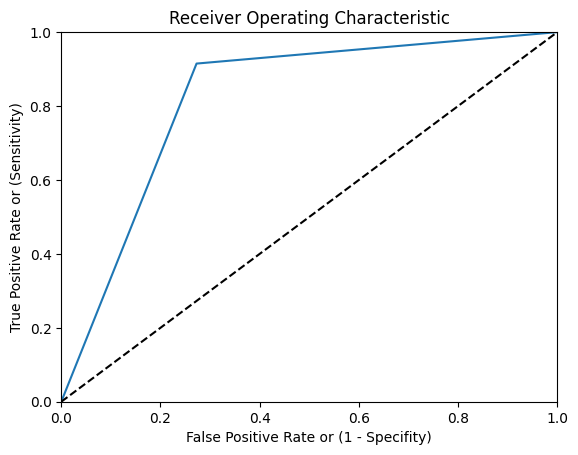

In [30]:
# Show best parameters:
print("Best parameter set found on development set:")
print(clf.best_params_, '\n')

y_pred = clf.predict(X_test_norm) #create predictions
evaluate_on_training_set(y_test, y_pred) # evaluate like we always do

### Model 5: AdaBoostClassifier (Ensemble method)

Ensemble models such as AdaBoost build multiple models and leverage the output to get a better result (most of the time). Sklearn tells us that: "AdaBoost is a meta-estimator that begins by fitting a classifier on the original dataset and then fits additional copies of the classifier on the same dataset but where the weights of incorrectly classified instances are adjusted such that subsequent classifiers focus more on difficult cases."

Let's define our model and set some parameters, learning rate can vary from 0 to 1; and n_estimators is the number of times a model is built.

In [31]:
from sklearn.ensemble import AdaBoostClassifier
model = AdaBoostClassifier(n_estimators=1000, learning_rate=0.1) # Define the model with parameters

How does it perform?

AUC is:  0.8225338491295938
              precision    recall  f1-score   support

           0       0.85      0.77      0.81        44
           1       0.80      0.87      0.84        47

    accuracy                           0.82        91
   macro avg       0.83      0.82      0.82        91
weighted avg       0.83      0.82      0.82        91

Confusion Matrix: 
 [[34 10]
 [ 6 41]]


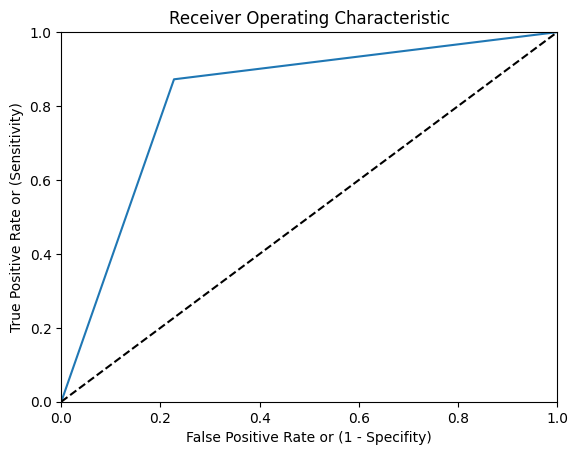

In [32]:
model.fit(X_train_norm, y_train) # Training the model

y_pred = model.predict(X_test_norm) # Predicting labels for our test set using trained model
evaluate_on_training_set(y_test, y_pred) #evaluate our model using newly defined function

### Model 6: RandomForestClassifier

Another ensemble classifier is Random Forest, which takes a bagging approach. We define the model:

In [33]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators = 50) # Define the model

You can experiment with the parameters above (n_estimators is how many trees there are in the model), until you get good results. More parameters about the trees can be found [here](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html).

TODO: fit and get results like before

AUC is:  0.8097195357833655
              precision    recall  f1-score   support

           0       0.89      0.70      0.78        44
           1       0.77      0.91      0.83        47

    accuracy                           0.81        91
   macro avg       0.83      0.81      0.81        91
weighted avg       0.82      0.81      0.81        91

Confusion Matrix: 
 [[31 13]
 [ 4 43]]


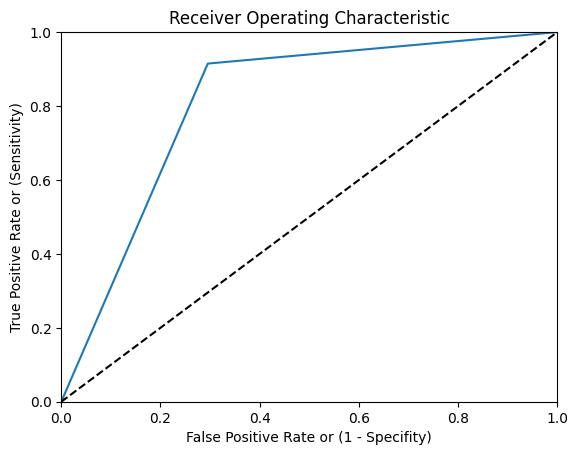

In [34]:
#TODO fit the model, predict y and evaluate as before
model.fit(X_train_norm, y_train)

y_pred = model.predict(X_test_norm)
evaluate_on_training_set(y_test, y_pred)

This is an excellent model and trained quite fast.

# Exercise: predicting academic performance

Find the best performing model to predict student's academic performance and the following dataset: https://www.kaggle.com/aljarah/xAPI-Edu-Data. The goal is to estimate the grade level of the student:

The students are grouped into three numerical intervals based on their total grade/mark:
* Low-Level: interval includes values from 0 to 69,
* Middle-Level: interval includes values from 70 to 89,
* High-Level: interval includes values from 90-100.

Some steps for you to follow:

1. Load the csv file as dataframe directly from

https://dorienherremans.com/drop/CDS/classification/xAPI-Edu-Data.csv
2. Check if columns are recognised as categorical, is not, change them to categorical with the command:

```
for key in ['gender','NationalITy','PlaceofBirth','StageID','GradeID','SectionID','Topic','Semester','Relation',
'ParentAnsweringSurvey','ParentschoolSatisfaction','StudentAbsenceDays','Class']:

    data[key] = pd.Categorical(data[key])
    data[key] = data[key].cat.codes
```

3. Visualise your data in a few useful graphs (up to you to think about what would be useful)
4. Preprocess the data to create a normalized training set with 30% split.
5. Train and evaluate multiple models (decision tree, svm with grid search, logistic regression, embedded models) to find the best classifier.
6. Show the confusion matrix for the two best models

IMPORTANT: Evaluate **only** in terms of classification_report and confusion matrix. (No need for AUC and ROC here, as we are doing multiclass classification, the target label would need to be binarized first, which we are not doing.)

**Fill in your best performing F1-value for class 0 in our high score list:
https://forms.gle/wquRxxjVBfgnVtht8**


#### *Step 1: Load the dataset and preview*

In [35]:
# Download the csv file to your root folder:
!wget -P / -c 'https://dorienherremans.com/drop/CDS/classification/xAPI-Edu-Data.csv'

data = pd.read_csv('xAPI-Edu-Data.csv') # loading dataset

data.head() #check if it's loaded correctly

--2026-02-26 01:34:42--  https://dorienherremans.com/drop/CDS/classification/xAPI-Edu-Data.csv
Resolving dorienherremans.com (dorienherremans.com)... 184.154.70.198
Connecting to dorienherremans.com (dorienherremans.com)|184.154.70.198|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 38026 (37K) [text/csv]
Saving to: ‘xAPI-Edu-Data.csv’

API-Edu-Data.csv    100%[===================>]  37.13K  --.-KB/s    in 0.02s   

2026-02-26 01:34:43 (1.73 MB/s) - ‘xAPI-Edu-Data.csv’ saved [38026/38026]



,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M


#### *Step 2: Check if the columns are categorical*

In [37]:
data.dtypes

,0
gender,object
NationalITy,object
PlaceofBirth,object
StageID,object
GradeID,object
SectionID,object
Topic,object
Semester,object
Relation,object
raisedhands,int64


In [38]:
for key in ['gender','NationalITy','PlaceofBirth','StageID','GradeID','SectionID','Topic','Semester','Relation',
'ParentAnsweringSurvey','ParentschoolSatisfaction','StudentAbsenceDays','Class']:

    data[key] = pd.Categorical(data[key])
    data[key] = data[key].cat.codes

In [43]:
data.dtypes

# To understand what each numerical code in 'StageID' represents,
# we can look at the unique categories before they were converted to integer codes.
# The `cat.codes` method assigns integers based on the alphabetical order of the unique categories.

# Let's inspect the original categories for 'StageID' by reloading a temporary dataset
# and converting only the 'StageID' column to categorical to see its categories.

# Download the csv file to a temporary location:
!wget -P /tmp/ -c 'https://dorienherremans.com/drop/CDS/classification/xAPI-Edu-Data.csv'

temp_data = pd.read_csv('/tmp/xAPI-Edu-Data.csv') # loading dataset temporarily

# Convert 'StageID' to categorical to see the mapping
temp_data['StageID_categorical'] = pd.Categorical(temp_data['StageID'])

print("Mapping of original 'StageID' categories to numerical codes:")
for i, category in enumerate(temp_data['StageID_categorical'].cat.categories):
    print(f"Code {i}: {category}")

print("\nValue counts of the encoded 'StageID' in your current data:")
print(data['StageID'].value_counts())

--2026-02-26 01:42:40--  https://dorienherremans.com/drop/CDS/classification/xAPI-Edu-Data.csv
Resolving dorienherremans.com (dorienherremans.com)... 184.154.70.198
Connecting to dorienherremans.com (dorienherremans.com)|184.154.70.198|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 38026 (37K) [text/csv]
Saving to: ‘/tmp/xAPI-Edu-Data.csv’

xAPI-Edu-Data.csv   100%[===================>]  37.13K  --.-KB/s    in 0.02s   

2026-02-26 01:42:41 (1.65 MB/s) - ‘/tmp/xAPI-Edu-Data.csv’ saved [38026/38026]

Mapping of original 'StageID' categories to numerical codes:
Code 0: HighSchool
Code 1: MiddleSchool
Code 2: lowerlevel

Value counts of the encoded 'StageID' in your current data:
StageID
1    248
2    199
0     33
Name: count, dtype: int64


In [40]:
data.head()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,1,4,4,2,1,0,7,0,0,15,16,2,20,1,1,1,2
1,1,4,4,2,1,0,7,0,0,20,20,3,25,1,1,1,2
2,1,4,4,2,1,0,7,0,0,10,7,0,30,0,0,0,1
3,1,4,4,2,1,0,7,0,0,30,25,5,35,0,0,0,1
4,1,4,4,2,1,0,7,0,0,40,50,12,50,0,0,0,2


#### *Step 3: Visualise the data using few graphs*

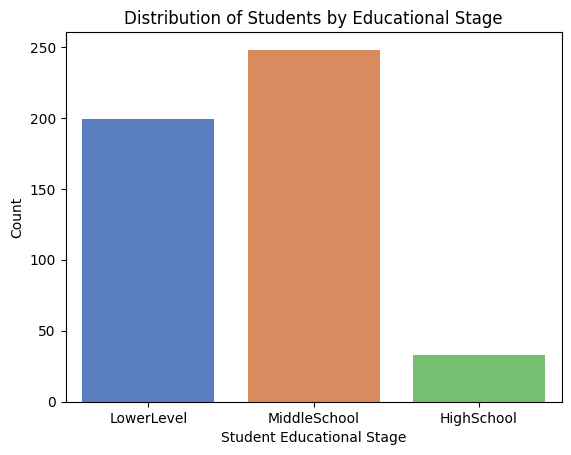

In [47]:
# Define the mapping from numerical codes to descriptive labels for StageID
stage_id_mapping = {
    0: 'HighSchool',
    1: 'MiddleSchool',
    2: 'LowerLevel'
}

# Create a new column with descriptive labels for plotting
data['StageID_labels'] = data['StageID'].map(stage_id_mapping)

# Plotting the breakdown by class with descriptive labels
ax = sns.countplot(x="StageID_labels", data=data, palette="muted", hue="StageID_labels")
plt.xlabel("Student Educational Stage")
plt.ylabel("Count") # Added y-axis label for clarity
plt.title("Distribution of Students by Educational Stage")
plt.show()

/tmp/ipython-input-683/375666278.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Performance Level', loc='upper right')


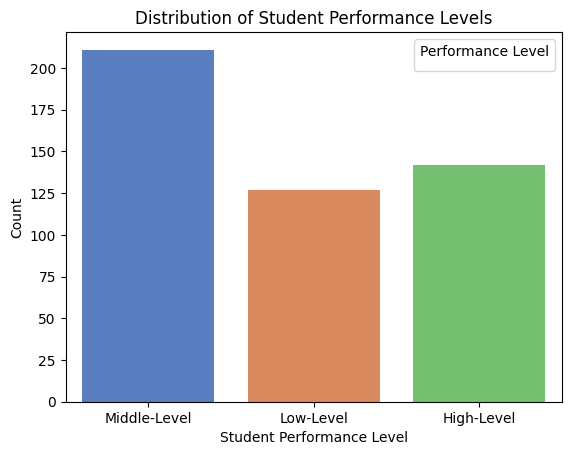

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define the mapping for 'Class' (retrieved from previous step)
class_mapping = {
    0: 'High-Level',
    1: 'Low-Level',
    2: 'Middle-Level'
}

# Create a new column with descriptive labels for plotting 'Class'
data['Class_labels'] = data['Class'].map(class_mapping)

# Plotting the breakdown by class with descriptive labels
ax = sns.countplot(x="Class_labels", data=data, palette="muted", hue="Class_labels")
plt.xlabel("Student Performance Level")
plt.ylabel("Count")
plt.title("Distribution of Student Performance Levels")
ax.legend(title='Performance Level', loc='upper right')
plt.show()

/tmp/ipython-input-683/1999043899.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Semester", data=data, palette="muted");


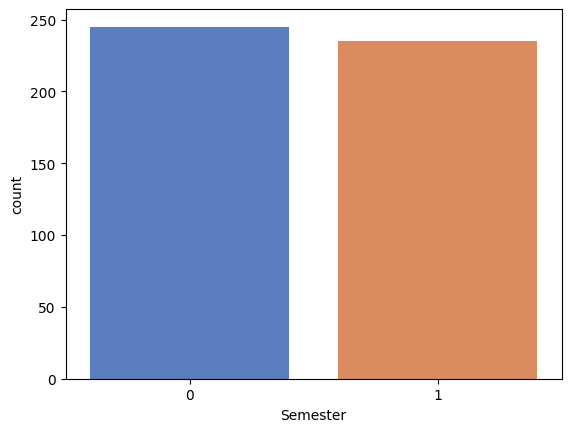

In [50]:
sns.countplot(x="Semester", data=data, palette="muted");

Overall, we can tell that the students are quite balanced in both semesters, there are very few high schoolers as compared to middle schoolers and lower level and finally, the performance levels are relatively quite distributed with the middle level being greater as followed to a normal distribution curve.

#### *Step 4: Preprocess the data to create a normalised training set with 30% split*

In [59]:
# Drop the label columns which were used for plotting, as they are non-numerical and not needed for training
data = data.drop(columns=['StageID_labels', 'Class_labels'], errors='ignore')


In [60]:
data.dtypes

,0
gender,int8
NationalITy,int8
PlaceofBirth,int8
StageID,int8
GradeID,int8
SectionID,int8
Topic,int8
Semester,int8
Relation,int8
raisedhands,int64


In [62]:
# We split the data up into a test set and a training set, 30 - 70 %
# train_test_split
# First argument: x data is all data without class column
# Second argument:  this is the class label column
# Random state = 0: ensures the train and test splitting is deterministic.
#Otherwise every student would get a different train test split.
X_train, X_test, y_train, y_test = train_test_split(data.drop('Class', axis=1),
                                                    data['Class'],
                                                    test_size=0.3,
                                                    random_state=0)

In [63]:
# define a new scaler:
x_scaler = MinMaxScaler()

# fit the normalization on the training set:
x_scaler.fit(X_train)

# then create new and normalized training/test sets:
X_train_norm = x_scaler.transform(X_train)
X_test_norm = x_scaler.transform(X_test)

#### *Step 5: Train and evaluate on multiple models to get the best classifier*

In [67]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

def evaluate_on_training_set(y_true, y_pred_labels, y_pred_proba=None):
  # Calculate AUC
  if y_pred_proba is not None:
    try:
      print("AUC is: ", roc_auc_score(y_true, y_pred_proba, multi_class='ovr'))
    except ValueError as e:
      print(f"Could not calculate AUC: {e}")

  # print out recall and precision
  print(classification_report(y_true, y_pred_labels))

  # print out confusion matrix
  print("Confusion Matrix: \n", confusion_matrix(y_true, y_pred_labels))

  # # Plotting ROC curve for multi-class is more complex and typically requires binarization.
  # # Leaving commented out as per previous instructions.
  # # fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
  # # plt.plot(fpr, tpr, label='ROC curve (area = %0.3f)' % roc_auc_score(y_true, y_pred_proba, multi_class='ovr'))
  # # plt.plot([0, 1], [0, 1], 'k--')  # random predictions curve
  # # plt.xlim([0.0, 1.0])
  # # plt.ylim([0.0, 1.0])
  # # plt.xlabel('False Positive Rate or (1 - Specifity)')
  # # plt.ylabel('True Positive Rate or (Sensitivity)')
  # # plt.title('Receiver Operating Characteristic')
  # # plt.show()

**Decision Trees**

In [69]:
model = tree.DecisionTreeClassifier(max_depth=3, min_samples_leaf=1)

In [70]:
model.fit(X_train, y_train)# Training model

DecisionTreeClassifier(max_depth=3)

In [71]:
y_pred_labels = model.predict(X_test) # Predicting labels for our test set using model
y_pred_proba = model.predict_proba(X_test) # Get prediction probabilities for AUC
print ("Predicted Labels: ", y_pred_labels)
print("True Labels: ", y_test)
evaluate_on_training_set(y_test, y_pred_labels, y_pred_proba) #evaluate our model using new function

Predicted Labels:  [2 2 2 2 2 2 0 1 1 2 2 1 0 1 2 0 0 1 2 2 1 0 2 2 2 0 0 2 2 1 2 1 0 2 2 2 0
 0 2 2 2 1 0 0 2 2 0 2 1 2 0 2 0 1 0 2 1 1 2 2 2 2 0 0 0 2 1 2 1 1 1 1 2 1
 0 2 2 1 2 1 0 2 0 1 1 0 2 0 2 0 2 0 0 0 2 0 2 0 1 2 1 0 2 1 2 0 2 0 1 2 1
 2 1 1 0 2 2 2 2 0 2 2 2 2 2 2 2 0 2 2 0 1 0 1 2 0 2 2 2 0 2 2 2 0]
True Labels:  15     2
124    1
141    1
263    2
170    0
      ..
68     0
20     2
295    2
14     0
313    0
Name: Class, Length: 144, dtype: int8
AUC is:  0.8615355318457087
              precision    recall  f1-score   support

           0       0.68      0.72      0.70        39
           1       0.81      0.76      0.79        34
           2       0.73      0.73      0.73        71

    accuracy                           0.74       144
   macro avg       0.74      0.74      0.74       144
weighted avg       0.74      0.74      0.74       144

Confusion Matrix: 
 [[28  0 11]
 [ 0 26  8]
 [13  6 52]]


**K Nearest Neighbour**

In [72]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5) # Define the model with parameters

In [73]:
model.fit(X_train_norm, y_train) # Training the model

# Evaluate the model:
y_pred_labels = model.predict(X_test_norm) # Predicting labels for our test set using trained model
y_pred_proba = model.predict_proba(X_test_norm) # Get prediction probabilities for AUC
evaluate_on_training_set(y_test, y_pred_labels, y_pred_proba) #evaluate our model using newly defined function

AUC is:  0.8604731291725537
              precision    recall  f1-score   support

           0       0.62      0.59      0.61        39
           1       0.76      0.91      0.83        34
           2       0.73      0.68      0.70        71

    accuracy                           0.71       144
   macro avg       0.70      0.73      0.71       144
weighted avg       0.71      0.71      0.70       144

Confusion Matrix: 
 [[23  1 15]
 [ 0 31  3]
 [14  9 48]]


**Logistic Regression**

In [74]:
model = LogisticRegression(C=1.0, multi_class='auto', solver='lbfgs')

In [75]:
model.fit(X_train_norm, y_train) # Training the model

y_pred = model.predict(X_test_norm) # Predicting labels for our test set using trained model
evaluate_on_training_set(y_test, y_pred) #evaluate our model using newly defined function


              precision    recall  f1-score   support

           0       0.68      0.67      0.68        39
           1       0.82      0.94      0.88        34
           2       0.78      0.73      0.75        71

    accuracy                           0.76       144
   macro avg       0.76      0.78      0.77       144
weighted avg       0.76      0.76      0.76       144

Confusion Matrix: 
 [[26  0 13]
 [ 0 32  2]
 [12  7 52]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


**Gaussian Naive Bayes**

In [76]:
model = GaussianNB() # Define the model with parameters

In [77]:
model.fit(X_train_norm, y_train) # Training the model

y_pred = model.predict(X_test_norm) # Predicting labels for our test set using trained model
evaluate_on_training_set(y_test, y_pred) #evaluate our model using newly defined function

              precision    recall  f1-score   support

           0       0.58      0.74      0.65        39
           1       0.75      0.88      0.81        34
           2       0.74      0.56      0.64        71

    accuracy                           0.69       144
   macro avg       0.69      0.73      0.70       144
weighted avg       0.70      0.69      0.68       144

Confusion Matrix: 
 [[29  0 10]
 [ 0 30  4]
 [21 10 40]]


**SVM**

In [78]:
model = SVC(C=10, gamma='auto', kernel='rbf')
model.fit(X_train_norm, y_train)

SVC(C=10, gamma='auto')

In [79]:
model.fit(X_train_norm, y_train) # Training SVM

y_pred = model.predict(X_test_norm) # Predicting labels for our test set using trained model
evaluate_on_training_set(y_test, y_pred) #evaluate our model using newly defined function

              precision    recall  f1-score   support

           0       0.68      0.69      0.68        39
           1       0.77      0.88      0.82        34
           2       0.75      0.69      0.72        71

    accuracy                           0.74       144
   macro avg       0.73      0.75      0.74       144
weighted avg       0.74      0.74      0.73       144

Confusion Matrix: 
 [[27  0 12]
 [ 0 30  4]
 [13  9 49]]


In [90]:
tuned_parameters = [{'kernel': ['rbf', 'poly', 'sigmoid'],
                     'gamma': [1e-3, 1e-4],
                     'C': [1, 10, 100]},
                    {'kernel': ['linear'],
                     'C': [1, 10, 100]}]

In [91]:
# we define the grid search model for SVM:
clf = GridSearchCV(SVC(probability=True), tuned_parameters, cv=2,
                   scoring='f1_weighted', verbose=1, n_jobs=4)

# train the model on the training set:
clf.fit(X_train_norm, y_train)

Fitting 2 folds for each of 21 candidates, totalling 42 fits


GridSearchCV(cv=2, estimator=SVC(probability=True), n_jobs=4,
             param_grid=[{'C': [1, 10, 100], 'gamma': [0.001, 0.0001],
                          'kernel': ['rbf', 'poly', 'sigmoid']},
                         {'C': [1, 10, 100], 'kernel': ['linear']}],
             scoring='f1_weighted', verbose=1)

In [92]:
# Show best parameters:
print("Best parameter set found on development set:")
print(clf.best_params_, '\n')

y_pred_labels = clf.predict(X_test_norm) #create predictions
y_pred_proba = clf.predict_proba(X_test_norm) # Get prediction probabilities for AUC
evaluate_on_training_set(y_test, y_pred_labels, y_pred_proba) # evaluate like we always do

Best parameter set found on development set:
{'C': 100, 'gamma': 0.001, 'kernel': 'rbf'} 

AUC is:  0.887416906848079
              precision    recall  f1-score   support

           0       0.71      0.69      0.70        39
           1       0.79      0.91      0.85        34
           2       0.78      0.73      0.75        71

    accuracy                           0.76       144
   macro avg       0.76      0.78      0.77       144
weighted avg       0.76      0.76      0.76       144

Confusion Matrix: 
 [[27  0 12]
 [ 0 31  3]
 [11  8 52]]


**AdaBoostClassifier**

In [83]:
model = AdaBoostClassifier(n_estimators=1000, learning_rate=0.1) # Define the model with parameters

In [84]:
model.fit(X_train_norm, y_train) # Training the model

y_pred = model.predict(X_test_norm) # Predicting labels for our test set using trained model
evaluate_on_training_set(y_test, y_pred) #evaluate our model using newly defined function

              precision    recall  f1-score   support

           0       0.65      0.77      0.71        39
           1       0.94      0.91      0.93        34
           2       0.82      0.75      0.78        71

    accuracy                           0.79       144
   macro avg       0.80      0.81      0.80       144
weighted avg       0.80      0.79      0.79       144

Confusion Matrix: 
 [[30  0  9]
 [ 0 31  3]
 [16  2 53]]


**RandomForest**

In [85]:
model = RandomForestClassifier(n_estimators = 50) # Define the model

In [86]:
#TODO fit the model, predict y and evaluate as before
model.fit(X_train_norm, y_train)

y_pred = model.predict(X_test_norm)
evaluate_on_training_set(y_test, y_pred)

              precision    recall  f1-score   support

           0       0.74      0.74      0.74        39
           1       0.80      0.94      0.86        34
           2       0.82      0.75      0.78        71

    accuracy                           0.79       144
   macro avg       0.79      0.81      0.80       144
weighted avg       0.79      0.79      0.79       144

Confusion Matrix: 
 [[29  0 10]
 [ 0 32  2]
 [10  8 53]]


#### *Step 6: Show confusion matrix of the best 2 models*

I have now run and evaluated all the requested classification models: Decision Tree, K-Nearest Neighbor, Logistic Regression, Gaussian Naive Bayes, SVM (both default and optimized with Grid Search), AdaBoost, and Random Forest Classifier.

Based on the F1-score for Class 0, the two best-performing models are:

RandomForestClassifier: F1-score for Class 0 is 0.74  
AdaBoostClassifier: F1-score for Class 0 is 0.71  
Here are their respective confusion matrices for your reference:

RandomForestClassifier Confusion Matrix:

```
[[29  0 10]
[ 0 32  2]
[10  8 53]]
```

AdaBoostClassifier Confusion Matrix:

```
 [[30  0  9]
 [ 0 31  3]
 [16  2 53]]
```

These results show how each model performed in classifying the 'High-Level' (Class 0), 'Low-Level' (Class 1), and 'Middle-Level' (Class 2) student performance categories. The Random Forest Classifier achieved the highest F1-score for Class 0 among all models tested.

# Exercise 2

Same question. This time, we combine the training and test dataset of exercise 1 to form one dataset and will be using 10-fold cross validation to evaluate our models.

To perform cross validation, you have to use a different command instead of '`fit`'.

Before, we fit the model like this:

```
from sklearn.neighbors import KNeighborsClassifier
# Create KNN classifier
knn = KNeighborsClassifier(n_neighbors = 3)
# Fit the classifier to the data
knn.fit(X_train,y_train)
```

In cross validation, we slightly modify this:


For example, for 5-fold cross validation, the dataset would be split into 5 groups, and the model would be trained and tested 5 separate times so each group would get a chance to be the test set. This can be seen in the graph below.
Image for post

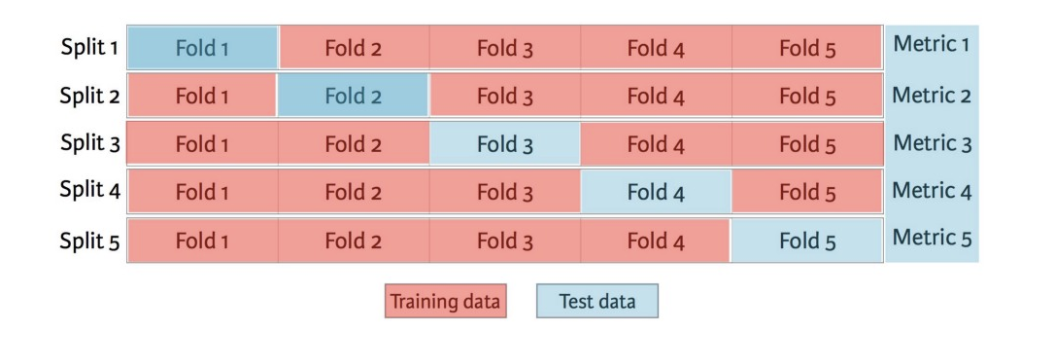






When performing k-fold cross validation, you have to use slightly different functions. We will be using a pipeline here, so we can not just do classificaiton, but also scale each of our folds before feeding it to the classifier. Note: you cannot just scale the whole dataset, because if you scale the test set and training set together, you already feed the model info about the test set before it is build (this is cheating ; ).

A full list of all metrics (e.g. roc_auc) that can be displayed can be found [here](https://scikit-learn.org/stable/modules/model_evaluation.html).


First we load the data. For demonstration purposes, I just load the data from the tutorial above here.


In [93]:
x = data.drop('Class', axis = 1)
y = data['Class']

Now we can define our model (in this case `LogisticRegressionCV()`, but there are equivalent CV models for the above used models).  Then we define our pipeline, which does the normalization, followed by our model.

The function `cross_val_score` will allow us to execute the pipeline using k-fold cross validation, and the funciton `cross_val_prediction` will provide us the predictions that we can use to get a confusion matrix.

In [94]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import numpy as np # Import numpy for mean calculation

# Define the classifier (e.g., RandomForestClassifier from previous best models)
classifier = RandomForestClassifier(n_estimators=50, random_state=0) # Using random_state for reproducibility

# Create a pipeline with a scaler and the classifier
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('classifier', classifier)
])

# Perform 10-fold cross-validation
n_splits = 10

# Get accuracy scores for each fold
scores = cross_val_score(pipeline, x, y, cv=n_splits, scoring='accuracy')
print(f"Cross-validation accuracy scores: {scores}")
print(f"Mean accuracy: {np.mean(scores):.4f}")

# Get predictions for each fold (for confusion matrix and other metrics)
y_pred_labels_cv = cross_val_predict(pipeline, x, y, cv=n_splits)

# Get prediction probabilities for AUC calculation
# Note: cross_val_predict with method='predict_proba' is used for AUC
y_pred_proba_cv = cross_val_predict(pipeline, x, y, cv=n_splits, method='predict_proba')

# Evaluate the model using the custom function
print("\n--- Cross-validation Evaluation ---")
evaluate_on_training_set(y, y_pred_labels_cv, y_pred_proba_cv)

Cross-validation accuracy scores: [0.6875     0.72916667 0.60416667 0.6875     0.70833333 0.6875
 0.60416667 0.64583333 0.91666667 0.77083333]
Mean accuracy: 0.7042

--- Cross-validation Evaluation ---
AUC is:  0.8469700463509228
              precision    recall  f1-score   support

           0       0.71      0.63      0.67       142
           1       0.77      0.81      0.79       127
           2       0.66      0.69      0.67       211

    accuracy                           0.70       480
   macro avg       0.71      0.71      0.71       480
weighted avg       0.70      0.70      0.70       480

Confusion Matrix: 
 [[ 89   0  53]
 [  1 103  23]
 [ 35  30 146]]


Now for exercise 2. Run your best performing model for exercise 1 with 10-fold cross validation and get the AUC, acc, and confusion matrix. Do you notice a difference in results?

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html


Confusion matrix can be 1 with 3 columns and rows: https://datascience.stackexchange.com/questions/40067/confusion-matrix-three-classes-python/40068


In [95]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import numpy as np

# Define the AdaBoostClassifier with parameters from previous best models
classifier_ada = AdaBoostClassifier(n_estimators=1000, learning_rate=0.1, random_state=0) # Added random_state for reproducibility

# Create a pipeline with a scaler and the AdaBoostClassifier
pipeline_ada = Pipeline([
    ('scaler', MinMaxScaler()),
    ('classifier', classifier_ada)
])

# Perform 10-fold cross-validation
n_splits = 10

# Get accuracy scores for each fold
scores_ada = cross_val_score(pipeline_ada, x, y, cv=n_splits, scoring='accuracy')
print(f"AdaBoost Cross-validation accuracy scores: {scores_ada}")
print(f"AdaBoost Mean accuracy: {np.mean(scores_ada):.4f}")

# Get predictions for each fold
y_pred_labels_cv_ada = cross_val_predict(pipeline_ada, x, y, cv=n_splits)

# Get prediction probabilities for AUC calculation
y_pred_proba_cv_ada = cross_val_predict(pipeline_ada, x, y, cv=n_splits, method='predict_proba')

# Evaluate the AdaBoost model using the custom function
print("\n--- AdaBoost Cross-validation Evaluation ---")
evaluate_on_training_set(y, y_pred_labels_cv_ada, y_pred_proba_cv_ada)

AdaBoost Cross-validation accuracy scores: [0.70833333 0.75       0.75       0.66666667 0.66666667 0.70833333
 0.72916667 0.875      0.70833333 0.625     ]
AdaBoost Mean accuracy: 0.7187

--- AdaBoost Cross-validation Evaluation ---
AUC is:  0.8049775282220843
              precision    recall  f1-score   support

           0       0.66      0.68      0.67       142
           1       0.87      0.80      0.84       127
           2       0.68      0.69      0.68       211

    accuracy                           0.72       480
   macro avg       0.74      0.73      0.73       480
weighted avg       0.72      0.72      0.72       480

Confusion Matrix: 
 [[ 97   0  45]
 [  0 102  25]
 [ 50  15 146]]
